In [ ]:
!pip install -q transformers datasets evaluate rouge_score accelerate

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.5 MB/s eta 0:00:00


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import GroupShuffleSplit
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)

import evaluate
from tqdm import tqdm
import random

# Verify GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Import the correct split function
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("curate_dataset_updated.csv", encoding="utf-8")

# Clean data: Drop any rows with missing values
df = df.dropna(subset=['fact_id', 'context', 'question', 'answer']).reset_index(drop=True)
print(f"Total valid rows: {len(df)}")

# We will Augment fallback class to improve balance
# Since you have 2817 standard vs 120 fallback, this helps
canonical_fallback = "I am an AI Docent dedicated to this gallery's collection."

standard_df = df[df['fact_id'] != 'global_docent_fallback'].copy()
fallback_df = df[df['fact_id'] == 'global_docent_fallback'].copy()

# Augment fallback data (creates versions of each fallback question)
augmented_rows = []
for _, row in fallback_df.iterrows():
    augmented_rows.append({
        'fact_id': row['fact_id'],
        'context': row['context'],
        'question': row['question'],
        'answer': canonical_fallback
    })

augmented_fallback_df = pd.DataFrame(augmented_rows)
df_balanced = pd.concat([standard_df, augmented_fallback_df], ignore_index=True)
print(f"After fallback augmentation: {len(df_balanced)} rows")
print(f"  Standard: {len(standard_df)} | Fallback (augmented): {len(augmented_fallback_df)}")

# YOUR STRATIFIED SPLIT: Maintains proportion of each fact_id
# This ensures ~80% of each theme's variations in training, ~20% in validation
train_df, val_df = train_test_split(
    df_balanced,  # Use augmented data
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['fact_id']  # CRITICAL: Maintains theme distribution
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Detailed distribution analysis
print(f"\n SPLIT DISTRIBUTION:")
print(f"Training set: {len(train_df)} rows ({len(train_df)/len(df_balanced)*100:.1f}%)")
print(f"Validation set: {len(val_df)} rows ({len(val_df)/len(df_balanced)*100:.1f}%)")

# Check distribution of each fact_id
print(f"\n Per theme breakdown:")
for fact_id in sorted(df_balanced['fact_id'].unique()):
    train_count = len(train_df[train_df['fact_id'] == fact_id])
    val_count = len(val_df[val_df['fact_id'] == fact_id])
    total = train_count + val_count
    train_pct = (train_count/total*100) if total > 0 else 0
    print(f"  {fact_id}: {train_count} train + {val_count} val = {total} total ({train_pct:.0f}% train)")

# Verify no data leakage (optional check)
train_fact_ids = set(train_df['fact_id'])
val_fact_ids = set(val_df['fact_id'])
overlap = train_fact_ids.intersection(val_fact_ids)
print(f"\n Data leakage check:")
print(f"  Overlapping fact_ids: {len(overlap)}")
print(f"  Note: Overlap is EXPECTED and CORRECT with stratified split")
print(f"  This ensures model learns all themes but tested on new variations")

# Convert to Hugging Face DatasetDict
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df)
})

print(f"\nDataset ready with stratified split!")

Total valid rows: 2936
After fallback augmentation: 2936 rows
  Standard: 2816 | Fallback (augmented): 120

 SPLIT DISTRIBUTION:
Training set: 2348 rows (80.0%)
Validation set: 588 rows (20.0%)

 Per theme breakdown:
  burninggiraffe_apolitical: 6 train + 2 val = 8 total (75% train)
  burninggiraffe_artist: 6 train + 2 val = 8 total (75% train)
  burninggiraffe_context: 6 train + 2 val = 8 total (75% train)
  burninggiraffe_crutches: 7 train + 1 val = 8 total (88% train)
  burninggiraffe_date: 6 train + 2 val = 8 total (75% train)
  burninggiraffe_description: 7 train + 1 val = 8 total (88% train)
  burninggiraffe_drawers: 7 train + 1 val = 8 total (88% train)
  burninggiraffe_dread: 7 train + 1 val = 8 total (88% train)
  burninggiraffe_exile: 6 train + 2 val = 8 total (75% train)
  burninggiraffe_figures: 7 train + 1 val = 8 total (88% train)
  burninggiraffe_freud: 7 train + 1 val = 8 total (88% train)
  burninggiraffe_giraffe: 6 train + 2 val = 8 total (75% train)
  burninggiraffe_

In [ ]:
# Load tokenizer
model_id = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Define preprocessing function with the strict Master Prompt Template
def preprocess_function(examples):
    # Construct the master prompt for every item in the batch
    inputs = [
        f"Answer the question based strictly on the context. If the answer cannot be found in the context, output exactly 'I am an AI Docent dedicated to this gallery's collection.' Context: {c} Question: {q}"
        for c, q in zip(examples['context'], examples['question'])
    ]

    # Tokenize inputs (max length 512 is well-suited for ~220 words)
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length") # ADDED PADDING MAX_LENGTH for stabilization

    # Tokenize labels (answers)
    labels = tokenizer(text_target=examples['answer'], max_length=128, truncation=True)
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

# Apply preprocessing to the datasets
tokenized_datasets = dataset.map(preprocess_function, batched=True, remove_columns=dataset["train"].column_names)
print("Tokenization complete.")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2348 [00:00<?, ? examples/s]

Map:   0%|          | 0/588 [00:00<?, ? examples/s]

Tokenization complete.


In [ ]:
# Load the pre-trained seq2seq model
model = AutoModelForSeq2SeqLM.from_pretrained(model_id).to(device)

# Initialize data collator to handle dynamic padding of inputs and labels
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

# Define training arguments optimized for a ~2,500 row dataset and a small model
training_args = Seq2SeqTrainingArguments(
    output_dir="./docent-flan-t5-base",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-4,             # reduced to 1e-4
    #Stability Tweaks
    warmup_ratio=0.1,           # Spend the first 10% of training "warming up"
    lr_scheduler_type="cosine", # Smoothly decays the LR as training progresses
    label_smoothing_factor=0.05, # Reduce to 0.05 (less noise, more precision)

    per_device_train_batch_size=8,   # Safe batch size to prevent OOM
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=2,              # Only keep the 2 most recent checkpoints to save space
    num_train_epochs=8,
    predict_with_generate=True,
    load_best_model_at_end=True,     # Critical: Loads the best model based on validation metrics
    metric_for_best_model="eval_loss",
    greater_is_better=False,          # Because we are evaluating based on loss
)

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
# Initialize Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
)

# Start fine-tuning
print("Starting training...")
trainer.train()
print("Training complete. Best model is currently loaded in memory.")

# Save the final best model locally
trainer.save_model("./docent-flan-t5-finetuned-tweaked1")

Starting training...


Epoch,Training Loss,Validation Loss
1,6.914125,3.934433
2,3.393223,2.085451
3,2.137438,1.445081
4,1.580825,1.172702
5,1.308435,1.049361
6,1.173851,0.993161
7,1.111000,0.969796
8,1.091012,0.967207


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Training complete. Best model is currently loaded in memory.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

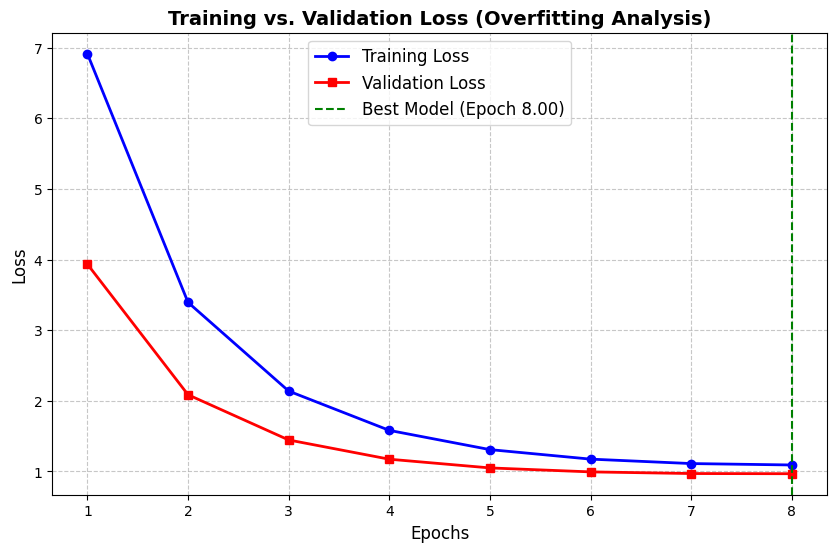

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_curve(trainer):
    """
    Extracts training and validation loss from the Hugging Face Trainer
    and plots them to detect overfitting.
    """
    log_history = trainer.state.log_history

    train_epochs = []
    train_loss = []
    val_epochs = []
    val_loss = []

    # Parse the logs
    for log in log_history:
        if 'loss' in log and 'epoch' in log:
            train_epochs.append(log['epoch'])
            train_loss.append(log['loss'])
        elif 'eval_loss' in log and 'epoch' in log:
            val_epochs.append(log['epoch'])
            val_loss.append(log['eval_loss'])

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_epochs, train_loss, label='Training Loss', color='blue', linewidth=2, marker='o')
    plt.plot(val_epochs, val_loss, label='Validation Loss', color='red', linewidth=2, marker='s')

    # Find the epoch with the lowest validation loss (The "Sweet Spot")
    if val_loss:
        best_val_loss = min(val_loss)
        best_epoch = val_epochs[val_loss.index(best_val_loss)]
        plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Model (Epoch {best_epoch:.2f})')

    # Formatting
    plt.title('Training vs. Validation Loss (Overfitting Analysis)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Display the diagram
    plt.show()

# Run the function using your trainer
plot_loss_curve(trainer)

In [ ]:
import random

def ask_docent_optimized(context, question, model, tokenizer):
    """
    Optimized inference using Beam Search for factual, exact-match answers.
    """
    model.eval()
    prompt = f"Answer the question based strictly on the context. If the answer cannot be found in the context, output exactly 'I am an AI Docent dedicated to this gallery's collection.' Context: {context} Question: {question}"

    inputs = tokenizer(prompt, return_tensors="pt", max_length=512, truncation=True).to(device)

    # UPDATED GENERATION SETTINGS
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=128,
            do_sample=False,       # Turn OFF creative sampling
            num_beams=5,           # Turn ON Beam Search (explores 4 paths for the best answer)
            length_penalty=1.2,
            early_stopping=True,   # Stop as soon as a complete sentence is formed
            repetition_penalty=1.2 # Slightly higher penalty to stop looping phrases
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


# --- Run on 5 Random Validation Samples ---
print("\n=== TESTING ON VALIDATION SET ===")
val_dataset = dataset["validation"]
# Pick 5 random indices
sample_indices = random.sample(range(len(val_dataset)), 5)

for idx in sample_indices:
    sample_context = val_dataset[idx]['context']
    sample_question = val_dataset[idx]['question']
    target_answer = val_dataset[idx]['answer']

    model_answer = ask_docent_optimized(sample_context, sample_question, model, tokenizer)

    print("-" * 50)
    print(f"QUESTION: {sample_question}")
    print(f"TARGET ANSWER: {target_answer}")
    print(f"DOCENT ANSWER: {model_answer}")


=== TESTING ON VALIDATION SET ===
--------------------------------------------------
QUESTION: What does the purple flower symbolize?
TARGET ANSWER: Symbolically, the violet acts as a shield, representing the masks individuals wear in polite society to hide their true identity or trauma.
DOCENT ANSWER: Symbolically, the violet acts as a shield, representing the masks individuals wear in polite society to hide their true identity or trauma.
--------------------------------------------------
QUESTION: Does this show the High Renaissance style?
TARGET ANSWER: This work epitomizes the High Renaissance's intellectual depth.
DOCENT ANSWER: The painting epitomizes the High Renaissance's intellectual depth.
--------------------------------------------------
QUESTION: What is the visual result of the looming hill?
TARGET ANSWER: These visual elements trap the figures within the frame.
DOCENT ANSWER: Notice the low horizon line and the looming hillside.
-----------------------------------------

In [ ]:
pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.7 MB/s eta 0:00:00


In [ ]:
import evaluate
from tqdm import tqdm
import numpy as np

# Load metrics (Perplexity removed to bypass the Hugging Face version bug)
rouge_metric = evaluate.load("rouge")
exact_match_metric = evaluate.load("exact_match")
bertscore_metric = evaluate.load("bertscore")
meteor_metric = evaluate.load("meteor")

def evaluate_model_on_validation(dataset, model, tokenizer):
    print("Starting evaluation on the validation set...")
    val_data = dataset["validation"]

    predictions = []
    references = []

    # Loop through the validation set
    for item in tqdm(val_data):
        context = item['context']
        question = item['question']
        target = item['answer']

        # Generate prediction using our optimized Beam Search function
        prediction = ask_docent_optimized(context, question, model, tokenizer)

        predictions.append(prediction)
        references.append(target)

    print("\nCalculating metrics... (BERTScore may take a moment)")

    # 1. Calculate Exact Match & ROUGE
    em_results = exact_match_metric.compute(predictions=predictions, references=references)
    rouge_results = rouge_metric.compute(predictions=predictions, references=references)

    # 2. Calculate METEOR
    meteor_results = meteor_metric.compute(predictions=predictions, references=references)

    # 3. Calculate BERTScore (lang="en" specifies English)
    bert_results = bertscore_metric.compute(predictions=predictions, references=references, lang="en")
    avg_bert_f1 = np.mean(bert_results['f1'])

    print("\n" + "="*40)
    print("=== FINAL EVALUATION METRICS ===")
    print("="*40)
    print(f"Exact Match: {em_results['exact_match'] * 100:.2f}%")
    print("-" * 40)
    print(f"ROUGE-1:     {rouge_results['rouge1'] * 100:.2f}%")
    print(f"ROUGE-2:     {rouge_results['rouge2'] * 100:.2f}%")
    print(f"ROUGE-L:     {rouge_results['rougeL'] * 100:.2f}%")
    print("-" * 40)
    print(f"METEOR:      {meteor_results['meteor'] * 100:.2f}%")
    print(f"BERTScore:   {avg_bert_f1 * 100:.2f}%  <-- (Semantic Accuracy)")
    print("="*40)

# Run the evaluation
evaluate_model_on_validation(dataset, model, tokenizer)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Starting evaluation on the validation set...


100%|██████████| 588/588 [05:14<00:00,  1.87it/s]



Calculating metrics... (BERTScore may take a moment)


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== FINAL EVALUATION METRICS ===
Exact Match: 52.38%
----------------------------------------
ROUGE-1:     74.46%
ROUGE-2:     69.96%
ROUGE-L:     74.18%
----------------------------------------
METEOR:      73.96%
BERTScore:   96.32%  <-- (Semantic Accuracy)


In [ ]:
def calculate_manual_perplexity(model, tokenized_dataset):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(tokenized_dataset):
            # Move batch to device
            input_ids = torch.tensor([batch['input_ids']]).to(device)
            labels = torch.tensor([batch['labels']]).to(device)

            outputs = model(input_ids=input_ids, labels=labels)
            total_loss += outputs.loss.item()

    avg_loss = total_loss / len(tokenized_dataset)
    perplexity = np.exp(avg_loss)
    return perplexity

# After your evaluation:
val_perp = calculate_manual_perplexity(model, tokenized_datasets["validation"])
print(f"Validation Perplexity: {val_perp:.2f}")

100%|██████████| 588/588 [00:55<00:00, 10.55it/s]

Validation Perplexity: 1.33


In [ ]:
# =========================
# CONFIG
# =========================
model_name = "docent-flan-t5-finetuned-tweaked1"
base_drive_path = "/content/drive/MyDrive/Curate_Docent_Models"

# =========================
# 1. MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# 2. CREATE MAIN FOLDER IF NOT EXISTS
# =========================
import os
os.makedirs(base_drive_path, exist_ok=True)

# =========================
# 3. DEFINE FINAL SAVE PATH
# =========================
final_path = os.path.join(base_drive_path, model_name)

# =========================
# 4. OVERWRITE IF EXISTS (for reruns)
# =========================
import shutil

if os.path.exists(final_path):
    print(f"Existing model found. Overwriting: {model_name}")
    shutil.rmtree(final_path)  # delete old version

# =========================
# 5. SAVE MODEL DIRECTLY TO DRIVE
# =========================
trainer.save_model(final_path)

print(f"Model saved to: {final_path}")

Mounted at /content/drive
Existing model found. Overwriting: docent-flan-t5-finetuned-tweaked1


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/Curate_Docent_Models/docent-flan-t5-finetuned-tweaked1


In [ ]:
def live_docent_chat():
    print("--- AI Docent Live Session (Type 'quit' to exit) ---")
    while True:
        context = input("\nEnter Context (or 'skip' to use a default): ")
        if context.lower() == 'quit': break

        # Example default context if they want to test questions quickly
        if context.lower() == 'skip':
            context = "The Starry Night is an oil-on-canvas painting by the Dutch Post-Impressionist painter Vincent van Gogh. Painted in June 1889, it depicts the view from the east-facing window of his asylum room at Saint-Rémy-de-Provence."
            print(f"Using Default Context: {context}")

        question = input("Your Question: ")
        if question.lower() == 'quit': break

        answer = ask_docent_optimized(context, question, model, tokenizer)
        print(f"\nDOCENT: {answer}")

# To run it:
live_docent_chat()

--- AI Docent Live Session (Type 'quit' to exit) ---

Enter Context (or 'skip' to use a default): skip
Using Default Context: The Starry Night is an oil-on-canvas painting by the Dutch Post-Impressionist painter Vincent van Gogh. Painted in June 1889, it depicts the view from the east-facing window of his asylum room at Saint-Rémy-de-Provence.
Your Question: title of the painting is?

DOCENT: The painting is entitled "The Barry Night".

Enter Context (or 'skip' to use a default): Painted when?
Your Question: shs

DOCENT: I am an AI Docent dedicated to this gallery's collection.

Enter Context (or 'skip' to use a default): skip
Using Default Context: The Starry Night is an oil-on-canvas painting by the Dutch Post-Impressionist painter Vincent van Gogh. Painted in June 1889, it depicts the view from the east-facing window of his asylum room at Saint-Rémy-de-Provence.
Your Question: painted when?

DOCENT: The artwork was painted in July 1889.

Enter Context (or 'skip' to use a default): T